# 07 — Construction d'Équipe Optimale pour chaque génération

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import requests
from math import pi

plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#F5F6FA',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

STATS = ['hp', 'attack', 'defense', 'special-attack', 'special-defense', 'speed']
TYPE_COLORS = {
    'normal': '#A8A878', 'fire': '#F08030', 'water': '#6890F0', 'electric': '#F8D030',
    'grass': '#78C850', 'ice': '#98D8D8', 'fighting': '#C03028', 'poison': '#A040A0',
    'ground': '#E0C068', 'flying': '#A890F0', 'psychic': '#F85888', 'bug': '#A8B820',
    'rock': '#B8A038', 'ghost': '#705898', 'dragon': '#7038F8', 'dark': '#705848',
    'steel': '#B8B8D0', 'fairy': '#EE99AC', 'stellar': '#40B5A5',
}
TEAM_COLORS = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6','#1ABC9C']

with open('../data/pokemon_full.pkl', 'rb') as f:
    data = pickle.load(f)
df, matrix, ALL_TYPES = data['df'], data['matrix'], data['ALL_TYPES']
print(f'Données chargées : {df.shape[0]} Pokémon')

gen_map = {
    'generation-i': 1, 'generation-ii': 2, 'generation-iii': 3,
    'generation-iv': 4, 'generation-v': 5, 'generation-vi': 6,
    'generation-vii': 7, 'generation-viii': 8, 'generation-ix': 9
}
df['generation'] = df['generation'].map(gen_map)

for gen, count in df['generation'].value_counts().sort_index().items():
    print(f"  Génération {int(gen)} : {count} Pokémon")

Données chargées : 1025 Pokémon
  Génération 1 : 151 Pokémon
  Génération 2 : 100 Pokémon
  Génération 3 : 135 Pokémon
  Génération 4 : 107 Pokémon
  Génération 5 : 156 Pokémon
  Génération 6 : 72 Pokémon
  Génération 7 : 88 Pokémon
  Génération 8 : 96 Pokémon
  Génération 9 : 120 Pokémon


## 1. Filtrage des pokémon

In [11]:
def compute_individual_scores(df, target_gen):
    gen_df = df[df['generation'] == target_gen].copy()
    gen_df['indiv_score'] = (
        gen_df['bst'].fillna(0)
        + 12 * gen_df['n_offense'].fillna(0)
        + 4  * gen_df['n_resistances'].fillna(0)
        - 6  * gen_df['n_weaknesses'].fillna(0)
        + 8  * gen_df['defense_score'].fillna(0)
    )
    return gen_df

## 2. Extraction du pool de candidats

In [12]:
def get_candidates(gen_df, pool_size=24):
    candidates = gen_df.nlargest(min(pool_size, len(gen_df)), 'indiv_score')
    return candidates.reset_index(drop=True)

## 3. Préparation des données pour le team building

In [13]:
def precompute_arrays(candidates, ALL_TYPES):
    bst_arr    = candidates['bst'].to_numpy(dtype=float)
    type1_arr  = candidates['type1'].fillna('').to_numpy()
    type2_arr  = candidates['type2'].fillna('').to_numpy()

    offense_sets = []
    for cov in candidates['offense_coverage']:
        if isinstance(cov, (set, list, tuple, np.ndarray)):
            offense_sets.append(set(cov))
        else:
            offense_sets.append(set())

    defense_arr = np.ones((len(candidates), len(ALL_TYPES)), dtype=float)
    for i, prof in enumerate(candidates['defense_profile']):
        if isinstance(prof, dict):
            defense_arr[i] = [float(prof.get(t, 1.0)) for t in ALL_TYPES]

    return bst_arr, type1_arr, type2_arr, offense_sets, defense_arr

## 4. Score team

In [14]:
def score_team(idxs, bst_arr, type1_arr, type2_arr, offense_sets, defense_arr):
    idxs   = np.array(idxs, dtype=int)
    power  = bst_arr[idxs].mean()

    cov    = set().union(*[offense_sets[i] for i in idxs])
    offense = len(cov) * 16

    team_types = {t for i in idxs for t in (type1_arr[i], type2_arr[i]) if t}
    diversity  = len(team_types) * 5

    m           = defense_arr[idxs]
    weak        = (m > 1).sum(axis=0)
    resist      = ((m < 1) & (m > 0)).sum(axis=0)
    immune      = (m == 0).sum(axis=0)
    weak_stacks = np.clip(weak - 2, 0, None).sum()
    defense     = resist.sum() * 1.3 + immune.sum() * 4 - weak_stacks * 10

    unique_primary = len({type1_arr[i] for i in idxs if type1_arr[i]})
    dup_penalty    = (len(idxs) - unique_primary) * 6

    return power + offense + diversity + defense - dup_penalty


## 5. Construction de la meilleure équipe

In [15]:
def build_best_team_df(candidates, best_idxs):
    team = candidates.iloc[list(best_idxs)].copy()
    team['pokemon'] = team['name'].str.replace('-', ' ').str.title()
    return team.sort_values('bst', ascending=False).reset_index(drop=True)

## 6. Visualisation de l'équipe optimale

In [18]:
def plot_radar(best_team_df, STATS, TEAM_COLORS, title):
    stats   = best_team_df.set_index('pokemon')[STATS]
    angles  = np.linspace(0, 2 * pi, len(STATS), endpoint=False).tolist() + [0]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})
    for i, (name, row) in enumerate(stats.iterrows()):
        ax.plot(angles, row.tolist() + [row.iloc[0]],
                color=TEAM_COLORS[i % len(TEAM_COLORS)], linewidth=2, label=name)

    mean_vals = stats.mean().tolist() + [stats.mean().iloc[0]]
    ax.plot(angles, mean_vals, color='#2C3E50', linewidth=3, linestyle='--', label='Moyenne équipe')
    ax.fill(angles, mean_vals, color='#2C3E50', alpha=0.12)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([s.replace('-', ' ').title() for s in STATS])
    ax.set_ylim(0, max(160, int(stats.to_numpy().max() + 20)))
    ax.set_title(title, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.38, 1.12), frameon=False)
    plt.tight_layout()
    plt.show()

# Génération 1

,pokemon,type1,type2,hp,attack,defense,special-attack,special-defense,speed,bst
0,Mewtwo,psychic,NaN,106,110,90,154,90,130,680
1,Dragonite,dragon,flying,91,134,95,100,100,80,600
2,Moltres,fire,flying,90,100,90,125,85,90,580
3,Poliwrath,water,fighting,90,95,95,70,90,70,510
4,Nidoqueen,poison,ground,90,92,87,75,85,76,505
5,Magneton,electric,steel,50,60,95,120,70,70,465


Score équipe: 925.5 | Couverture offensive: 16/19 types


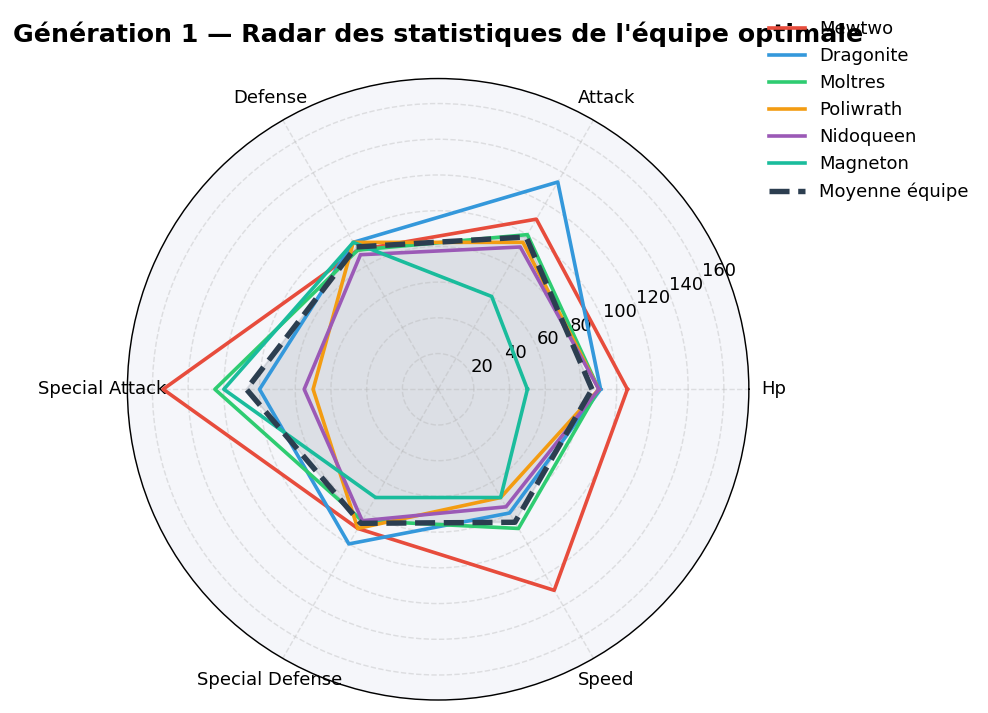

In [ ]:
GEN = 1

gen1_df    = compute_individual_scores(df, GEN)
candidates = get_candidates(gen1_df)
arrays     = precompute_arrays(candidates, ALL_TYPES)
bst_arr, type1_arr, type2_arr, offense_sets, defense_arr = arrays

scorer     = lambda idxs: score_team(idxs, *arrays)

best_team  = build_best_team_df(candidates, best_idxs)
team_cov   = set().union(*[offense_sets[i] for i in best_idxs])

display(best_team[['pokemon', 'type1', 'type2', 'hp', 'attack',
                    'defense', 'special-attack', 'special-defense', 'speed', 'bst']])
print(f"Score équipe: {best_score:.1f} | Couverture offensive: {len(team_cov)}/{len(ALL_TYPES)} types")

plot_radar(best_team, STATS, TEAM_COLORS, f"Génération {GEN} — Radar des statistiques de l'équipe optimale")

# Génération 2

,pokemon,type1,type2,hp,attack,defense,special-attack,special-defense,speed,bst
0,Lugia,psychic,flying,106,90,130,90,154,110,680
1,Raikou,electric,NaN,90,85,75,115,100,115,580
2,Steelix,steel,ground,75,85,200,55,65,30,510
3,Scizor,bug,steel,70,130,100,55,80,65,500
4,Mantine,water,flying,85,40,70,80,140,70,485
5,Forretress,bug,steel,75,90,140,60,60,40,465


Score équipe: 925.5 | Couverture offensive: 15/19 types


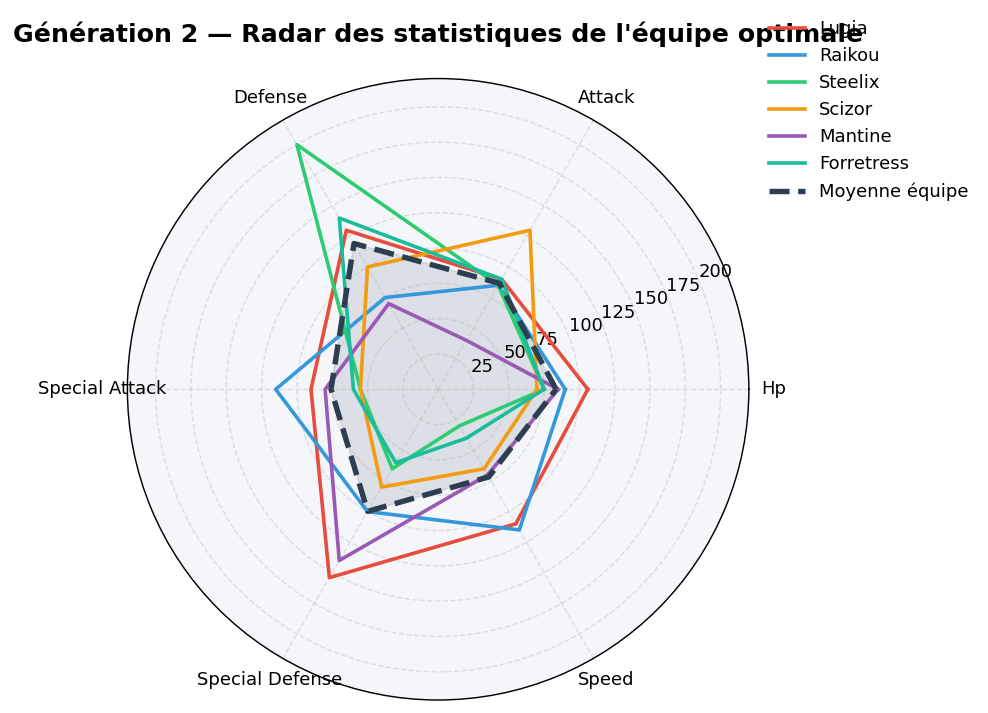

In [23]:
GEN = 2

gen1_df    = compute_individual_scores(df, GEN)
candidates = get_candidates(gen1_df)
arrays     = precompute_arrays(candidates, ALL_TYPES)
bst_arr, type1_arr, type2_arr, offense_sets, defense_arr = arrays

scorer     = lambda idxs: score_team(idxs, *arrays)

best_team  = build_best_team_df(candidates, best_idxs)
team_cov   = set().union(*[offense_sets[i] for i in best_idxs])

display(best_team[['pokemon', 'type1', 'type2', 'hp', 'attack',
                    'defense', 'special-attack', 'special-defense', 'speed', 'bst']])
print(f"Score équipe: {best_score:.1f} | Couverture offensive: {len(team_cov)}/{len(ALL_TYPES)} types")

plot_radar(best_team, STATS, TEAM_COLORS, f"Génération {GEN} — Radar des statistiques de l'équipe optimale")

# Génération 3

,pokemon,type1,type2,hp,attack,defense,special-attack,special-defense,speed,bst
0,Groudon,ground,NaN,100,150,140,100,90,90,670
1,Metagross,steel,psychic,80,135,130,95,90,70,600
2,Jirachi,steel,psychic,100,100,100,100,100,100,600
3,Salamence,dragon,flying,95,135,80,110,80,100,600
4,Latios,dragon,psychic,80,90,80,130,110,110,600
5,Blaziken,fire,fighting,80,120,70,110,70,80,530


Score équipe: 925.5 | Couverture offensive: 13/19 types


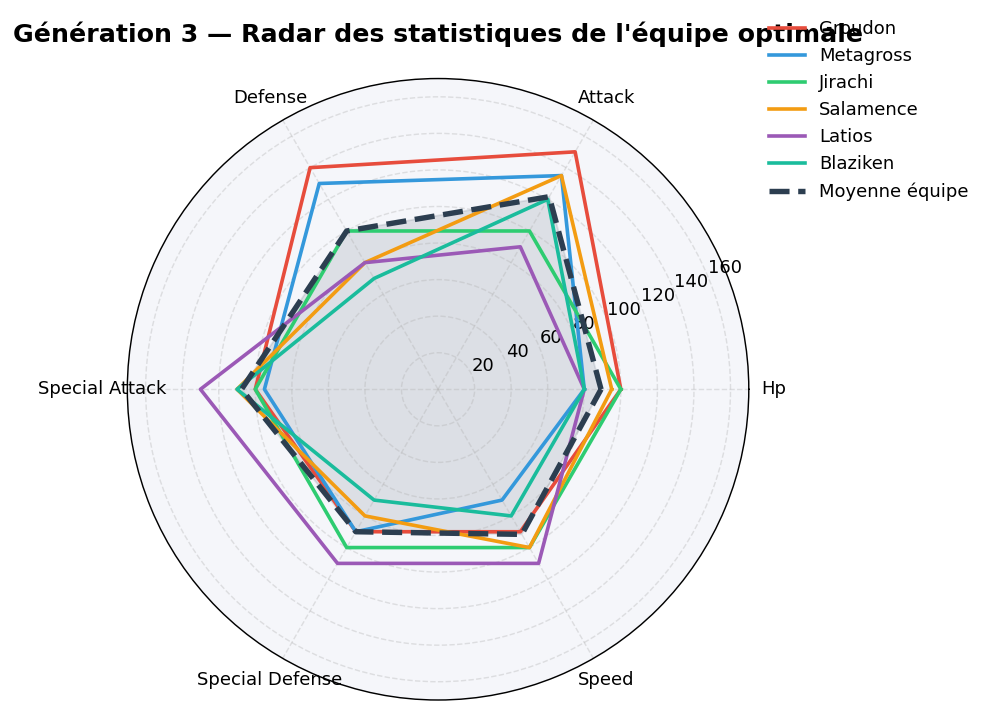

In [24]:
GEN = 3

gen1_df    = compute_individual_scores(df, GEN)
candidates = get_candidates(gen1_df)
arrays     = precompute_arrays(candidates, ALL_TYPES)
bst_arr, type1_arr, type2_arr, offense_sets, defense_arr = arrays

scorer     = lambda idxs: score_team(idxs, *arrays)

best_team  = build_best_team_df(candidates, best_idxs)
team_cov   = set().union(*[offense_sets[i] for i in best_idxs])

display(best_team[['pokemon', 'type1', 'type2', 'hp', 'attack',
                    'defense', 'special-attack', 'special-defense', 'speed', 'bst']])
print(f"Score équipe: {best_score:.1f} | Couverture offensive: {len(team_cov)}/{len(ALL_TYPES)} types")

plot_radar(best_team, STATS, TEAM_COLORS, f"Génération {GEN} — Radar des statistiques de l'équipe optimale")

# Génération 4

,pokemon,type1,type2,hp,attack,defense,special-attack,special-defense,speed,bst
0,Giratina Altered,ghost,dragon,150,100,120,100,120,90,680
1,Palkia,water,dragon,90,120,100,150,120,100,680
2,Regigigas,normal,NaN,110,160,110,80,110,100,670
3,Heatran,fire,steel,91,90,106,130,106,77,600
4,Probopass,rock,steel,60,55,145,75,150,40,525
5,Gliscor,ground,flying,75,95,125,45,75,95,510


Score équipe: 925.5 | Couverture offensive: 15/19 types


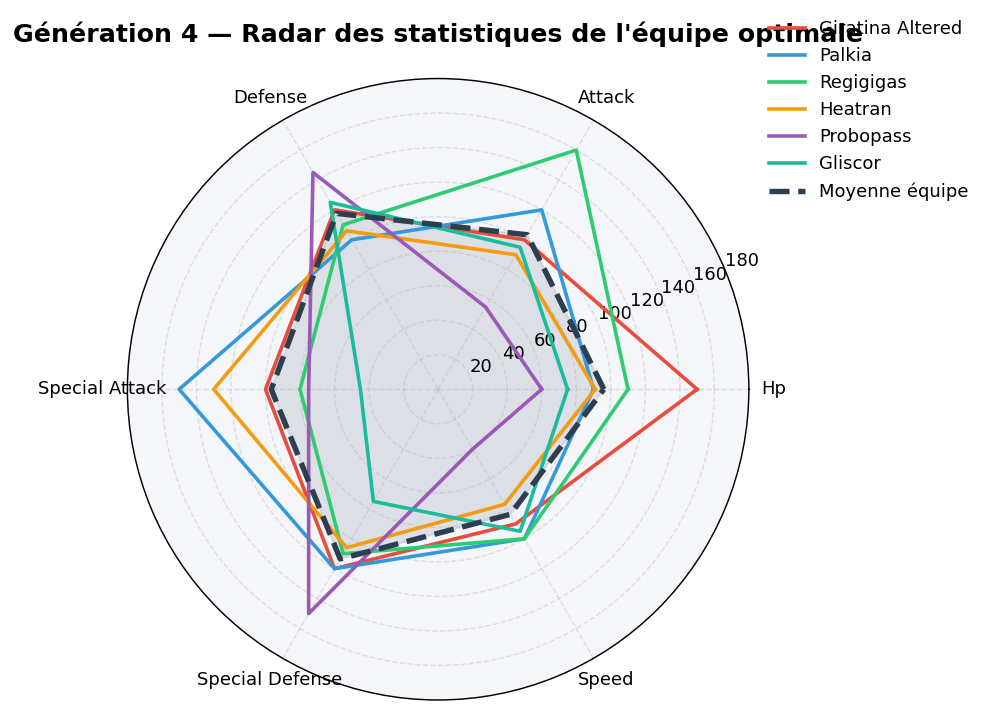

In [25]:
GEN = 4

gen1_df    = compute_individual_scores(df, GEN)
candidates = get_candidates(gen1_df)
arrays     = precompute_arrays(candidates, ALL_TYPES)
bst_arr, type1_arr, type2_arr, offense_sets, defense_arr = arrays

scorer     = lambda idxs: score_team(idxs, *arrays)

best_team  = build_best_team_df(candidates, best_idxs)
team_cov   = set().union(*[offense_sets[i] for i in best_idxs])

display(best_team[['pokemon', 'type1', 'type2', 'hp', 'attack',
                    'defense', 'special-attack', 'special-defense', 'speed', 'bst']])
print(f"Score équipe: {best_score:.1f} | Couverture offensive: {len(team_cov)}/{len(ALL_TYPES)} types")

plot_radar(best_team, STATS, TEAM_COLORS, f"Génération {GEN} — Radar des statistiques de l'équipe optimale")

# Génération 5

,pokemon,type1,type2,hp,attack,defense,special-attack,special-defense,speed,bst
0,Reshiram,dragon,fire,100,120,100,150,120,90,680
1,Zekrom,dragon,electric,100,150,120,120,100,90,680
2,Kyurem,dragon,ice,125,130,90,130,90,95,660
3,Landorus Incarnate,ground,flying,89,125,90,115,80,101,600
4,Hydreigon,dark,dragon,92,105,90,125,90,98,600
5,Excadrill,ground,steel,110,135,60,50,65,88,508


Score équipe: 925.5 | Couverture offensive: 16/19 types


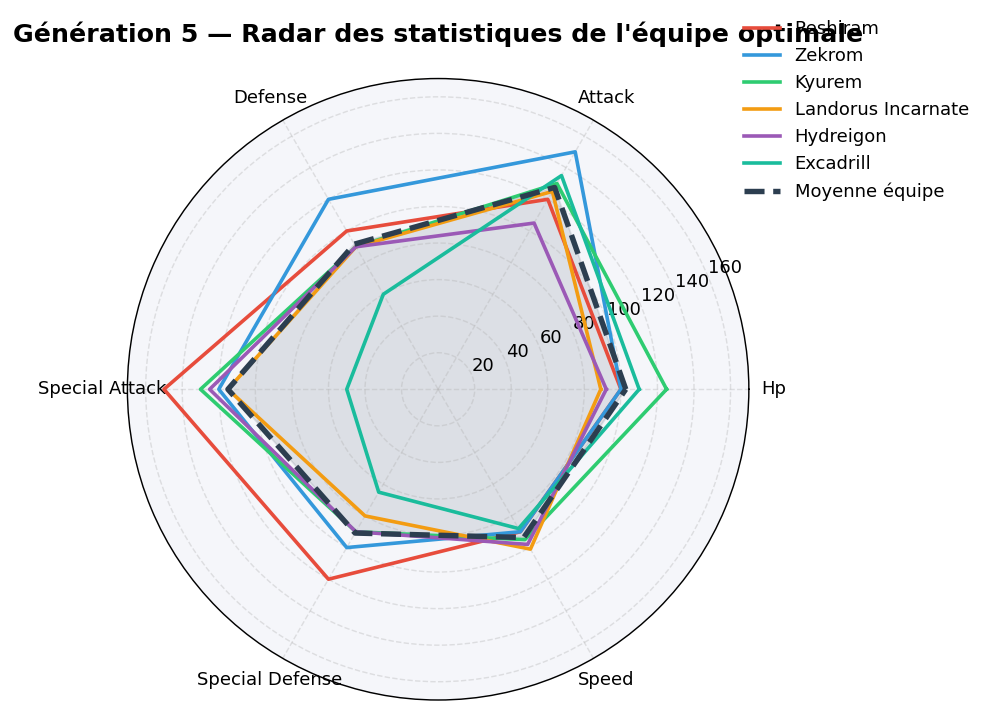

In [26]:
GEN = 5

gen1_df    = compute_individual_scores(df, GEN)
candidates = get_candidates(gen1_df)
arrays     = precompute_arrays(candidates, ALL_TYPES)
bst_arr, type1_arr, type2_arr, offense_sets, defense_arr = arrays

scorer     = lambda idxs: score_team(idxs, *arrays)

best_team  = build_best_team_df(candidates, best_idxs)
team_cov   = set().union(*[offense_sets[i] for i in best_idxs])

display(best_team[['pokemon', 'type1', 'type2', 'hp', 'attack',
                    'defense', 'special-attack', 'special-defense', 'speed', 'bst']])
print(f"Score équipe: {best_score:.1f} | Couverture offensive: {len(team_cov)}/{len(ALL_TYPES)} types")

plot_radar(best_team, STATS, TEAM_COLORS, f"Génération {GEN} — Radar des statistiques de l'équipe optimale")

# Génération 6

,pokemon,type1,type2,hp,attack,defense,special-attack,special-defense,speed,bst
0,Xerneas,fairy,NaN,126,131,95,131,98,99,680
1,Diancie,rock,fairy,50,100,150,100,150,50,600
2,Volcanion,fire,water,80,110,120,130,90,70,600
3,Florges,fairy,NaN,78,65,68,112,154,75,552
4,Delphox,fire,psychic,75,69,72,114,100,104,534
5,Doublade,steel,ghost,59,110,150,45,49,35,448


Score équipe: 925.5 | Couverture offensive: 15/19 types


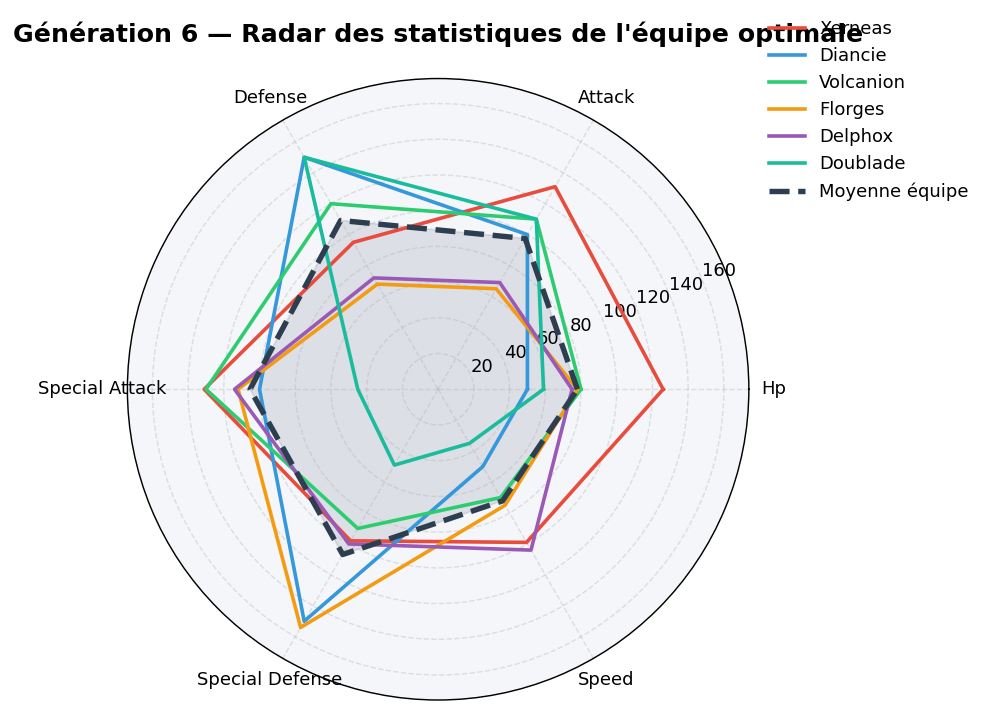

In [27]:
GEN = 6

gen1_df    = compute_individual_scores(df, GEN)
candidates = get_candidates(gen1_df)
arrays     = precompute_arrays(candidates, ALL_TYPES)
bst_arr, type1_arr, type2_arr, offense_sets, defense_arr = arrays

scorer     = lambda idxs: score_team(idxs, *arrays)

best_team  = build_best_team_df(candidates, best_idxs)
team_cov   = set().union(*[offense_sets[i] for i in best_idxs])

display(best_team[['pokemon', 'type1', 'type2', 'hp', 'attack',
                    'defense', 'special-attack', 'special-defense', 'speed', 'bst']])
print(f"Score équipe: {best_score:.1f} | Couverture offensive: {len(team_cov)}/{len(ALL_TYPES)} types")

plot_radar(best_team, STATS, TEAM_COLORS, f"Génération {GEN} — Radar des statistiques de l'équipe optimale")

# Génération 7

,pokemon,type1,type2,hp,attack,defense,special-attack,special-defense,speed,bst
0,Lunala,psychic,ghost,137,113,89,137,107,97,680
1,Magearna,steel,fairy,80,95,115,130,115,65,600
2,Kommo O,dragon,fighting,75,110,125,100,105,85,600
3,Celesteela,steel,flying,97,101,103,107,101,61,570
4,Tapu Fini,water,fairy,70,75,115,95,130,85,570
5,Tapu Bulu,grass,fairy,70,130,115,85,95,75,570


Score équipe: 925.5 | Couverture offensive: 16/19 types


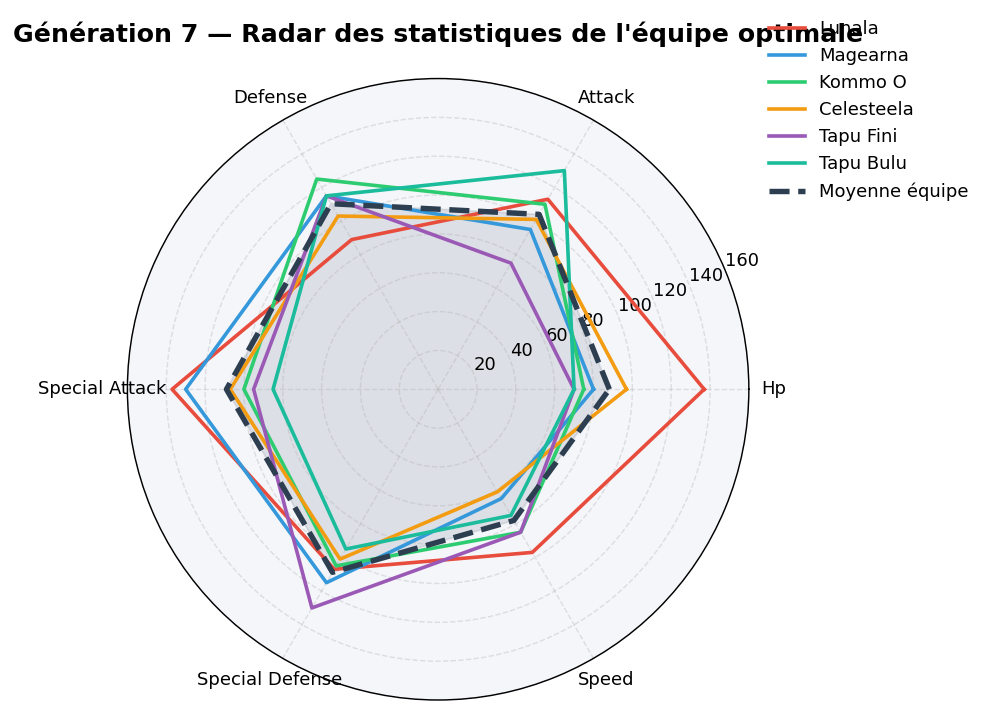

In [28]:
GEN = 7

gen1_df    = compute_individual_scores(df, GEN)
candidates = get_candidates(gen1_df)
arrays     = precompute_arrays(candidates, ALL_TYPES)
bst_arr, type1_arr, type2_arr, offense_sets, defense_arr = arrays

scorer     = lambda idxs: score_team(idxs, *arrays)

best_team  = build_best_team_df(candidates, best_idxs)
team_cov   = set().union(*[offense_sets[i] for i in best_idxs])

display(best_team[['pokemon', 'type1', 'type2', 'hp', 'attack',
                    'defense', 'special-attack', 'special-defense', 'speed', 'bst']])
print(f"Score équipe: {best_score:.1f} | Couverture offensive: {len(team_cov)}/{len(ALL_TYPES)} types")

plot_radar(best_team, STATS, TEAM_COLORS, f"Génération {GEN} — Radar des statistiques de l'équipe optimale")

# Génération 8

,pokemon,type1,type2,hp,attack,defense,special-attack,special-defense,speed,bst
0,Zacian,fairy,NaN,92,120,115,80,115,138,660
1,Zamazenta,fighting,NaN,92,120,115,80,115,138,660
2,Spectrier,ghost,NaN,100,65,60,145,80,130,580
3,Urshifu Single Strike,fighting,dark,100,130,100,63,60,97,550
4,Duraludon,steel,dragon,70,95,115,120,50,85,535
5,Centiskorch,fire,bug,100,115,65,90,90,65,525


Score équipe: 925.5 | Couverture offensive: 12/19 types


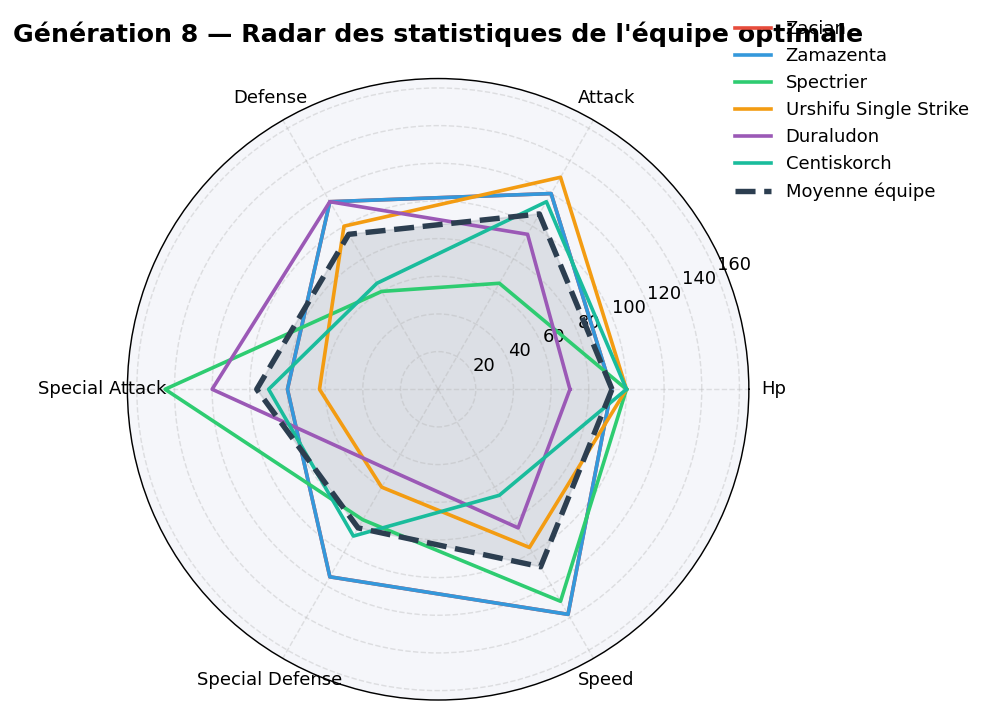

In [29]:
GEN = 8

gen1_df    = compute_individual_scores(df, GEN)
candidates = get_candidates(gen1_df)
arrays     = precompute_arrays(candidates, ALL_TYPES)
bst_arr, type1_arr, type2_arr, offense_sets, defense_arr = arrays

scorer     = lambda idxs: score_team(idxs, *arrays)

best_team  = build_best_team_df(candidates, best_idxs)
team_cov   = set().union(*[offense_sets[i] for i in best_idxs])

display(best_team[['pokemon', 'type1', 'type2', 'hp', 'attack',
                    'defense', 'special-attack', 'special-defense', 'speed', 'bst']])
print(f"Score équipe: {best_score:.1f} | Couverture offensive: {len(team_cov)}/{len(ALL_TYPES)} types")

plot_radar(best_team, STATS, TEAM_COLORS, f"Génération {GEN} — Radar des statistiques de l'équipe optimale")

# Génération 9

,pokemon,type1,type2,hp,attack,defense,special-attack,special-defense,speed,bst
0,Miraidon,electric,dragon,100,85,100,135,115,135,670
1,Archaludon,steel,dragon,90,105,130,125,65,85,600
2,Pecharunt,poison,ghost,88,88,160,88,88,88,600
3,Iron Treads,ground,steel,90,112,120,72,70,106,570
4,Chi Yu,dark,fire,55,80,80,135,120,100,570
5,Okidogi,poison,fighting,88,128,115,58,86,80,555


Score équipe: 925.5 | Couverture offensive: 16/19 types


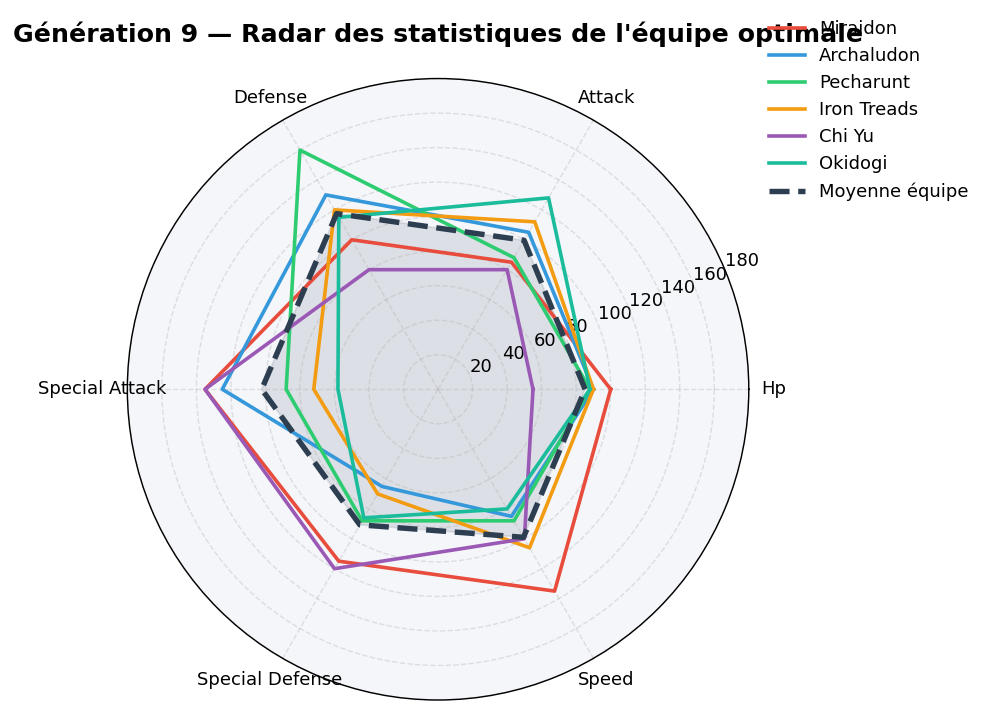

In [30]:
GEN = 9

gen1_df    = compute_individual_scores(df, GEN)
candidates = get_candidates(gen1_df)
arrays     = precompute_arrays(candidates, ALL_TYPES)
bst_arr, type1_arr, type2_arr, offense_sets, defense_arr = arrays

scorer     = lambda idxs: score_team(idxs, *arrays)

best_team  = build_best_team_df(candidates, best_idxs)
team_cov   = set().union(*[offense_sets[i] for i in best_idxs])

display(best_team[['pokemon', 'type1', 'type2', 'hp', 'attack',
                    'defense', 'special-attack', 'special-defense', 'speed', 'bst']])
print(f"Score équipe: {best_score:.1f} | Couverture offensive: {len(team_cov)}/{len(ALL_TYPES)} types")

plot_radar(best_team, STATS, TEAM_COLORS, f"Génération {GEN} — Radar des statistiques de l'équipe optimale")